Columns and Data Types:
 Date      datetime64[ns]
Close             object
High              object
Low               object
Open              object
Volume            object
dtype: object

Sample data:
         Date              Close               High                Low  \
0        NaT               AAPL               AAPL               AAPL   
1 2020-06-04  78.32931518554688   79.1312690763083  77.95506657558614   
2 2020-06-05  80.56021881103516  80.62097312386399  78.55046881252456   
3 2020-06-08  81.03653717041016  81.07056314819836  79.54441498185327   
4 2020-06-09  83.59550476074219  83.98919153470604  80.68416273702039   

                Open     Volume  
0               AAPL       AAPL  
1  78.83236263047952   87560400  
2  78.57962969607472  137250400  
3  80.25645380649277   95654400  
4  80.71575616737768  147712400  

After conversion, data types:
 Close     float64
High      float64
Low       float64
Open      float64
Volume    float64
dtype: object


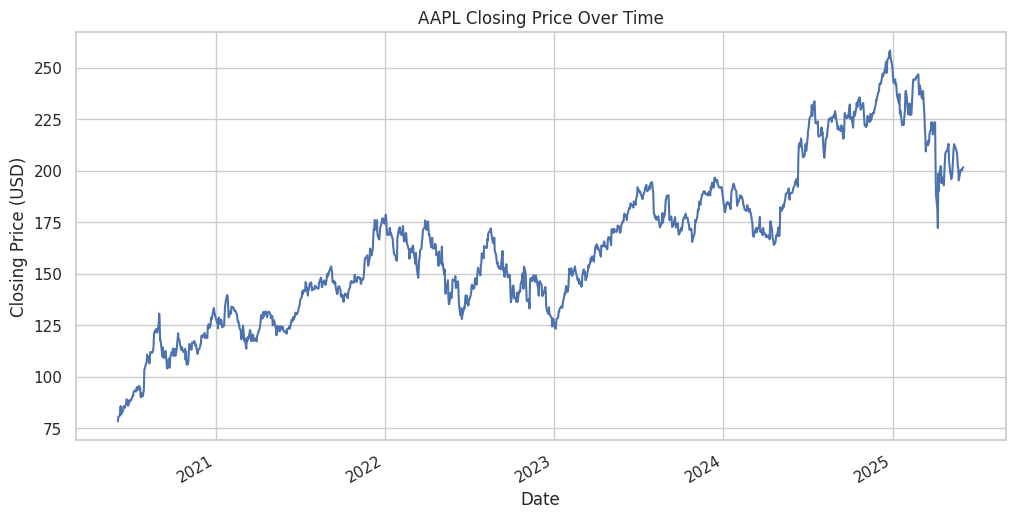

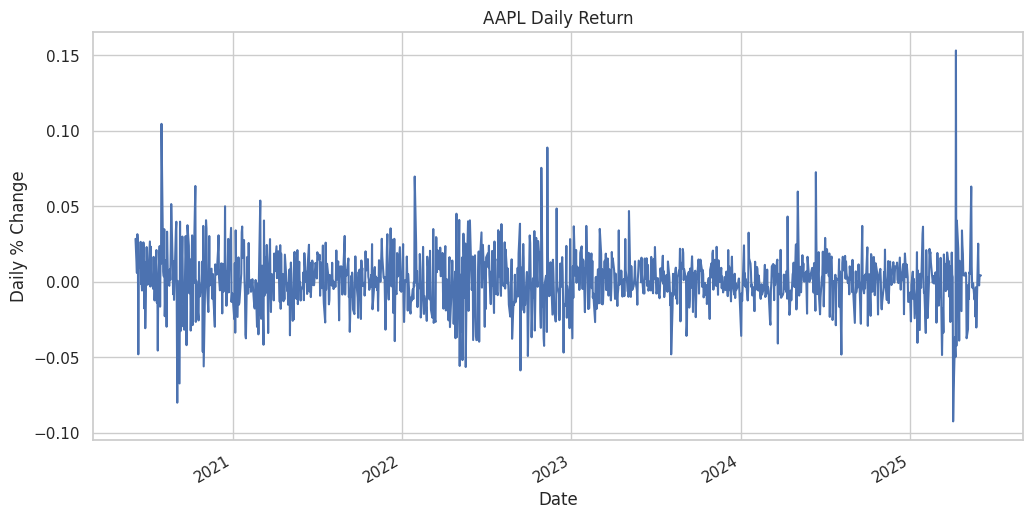

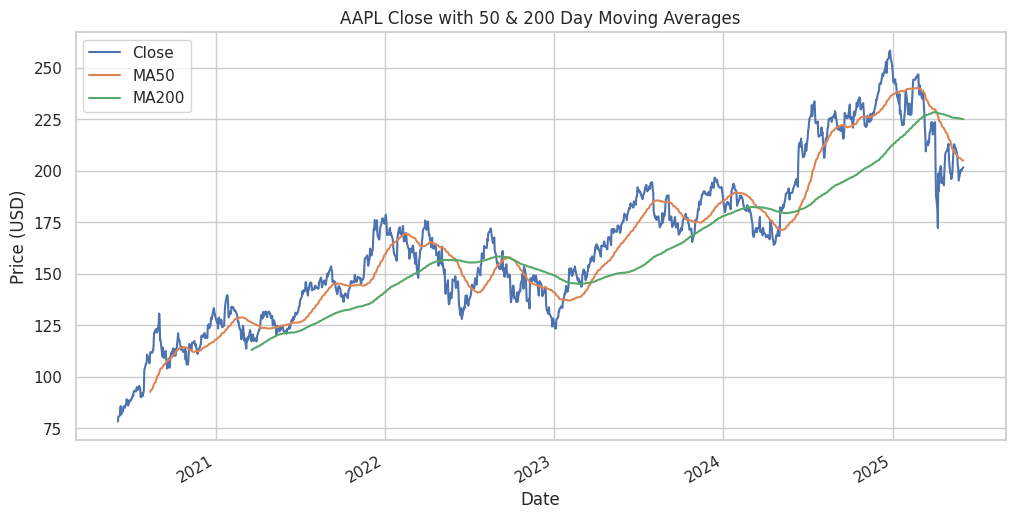

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plots
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Load dataset
df = pd.read_csv("/kaggle/input/2020-2025-apple-stock-dataset/apple_5yr_one.csv", parse_dates=["Date"])

# Preview columns and types to debug
print("Columns and Data Types:\n", df.dtypes)
print("\nSample data:\n", df.head())

# Strip whitespace from column names if any
df.columns = df.columns.str.strip()

# Set date as index
df.set_index("Date", inplace=True)
df.sort_index(inplace=True)

# Convert columns to numeric, coercing errors (invalid parsing become NaN)
for col in ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    else:
        print(f"Warning: Column '{col}' not found in dataset.")

# Drop rows with missing values to ensure plotting works
df.dropna(subset=['Close'], inplace=True)

print("\nAfter conversion, data types:\n", df.dtypes)

# Plot closing price
df['Close'].plot(title="AAPL Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.show()

# Calculate and plot daily returns
df['Daily Return'] = df['Close'].pct_change()
df['Daily Return'].plot(title="AAPL Daily Return")
plt.xlabel("Date")
plt.ylabel("Daily % Change")
plt.show()

# Moving averages
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

df[['Close', 'MA50', 'MA200']].plot(title="AAPL Close with 50 & 200 Day Moving Averages")
plt.ylabel("Price (USD)")
plt.show()
